# Hands-On Assignment: AI Module 6

**GitHub Repository Portfolio:** https://github.com/bagasapt-spec/gdgoc-ai-handson

# Hands-On Task: Handwritten Digit Classification Pipeline with MLP & Keras

Proyek ini membangun end-to-end deep learning classification pipeline menggunakan Scikit-learn dan TensorFlow/Keras untuk mengklasifikasikan citra angka tulisan tangan 8x8 piksel pada dataset load_digits. Alur kerja mencakup eksplorasi visual data, standarisasi fitur, pelatihan baseline Multi-Layer Perceptron (MLP) dengan analisis learning curve (deteksi overfitting), regularisasi melalui early stopping dan tuning hyperparameter (GridSearchCV), hingga perbandingan terhadap arsitektur Keras Sequential serta analisis citra salah klasifikasi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)

print("Pustaka utama berhasil dimuat.")

Pustaka utama berhasil dimuat.


# Stage 1: Data Loading, EDA, and Preprocessing

## 1.1 Eksplorasi Visual dan Pembagian Dataset

Dataset `load_digits` memuat 1.797 sampel citra skala abu-abu berukuran 8x8 piksel (total 64 fitur) yang merepresentasikan angka 0 hingga 9.

Tahapan persiapan data:
* Menampilkan dimensi matriks fitur X dan target y, serta memvisualisasikan 10 citra pertama beserta labelnya.
* Membagi data menjadi 70% data latih dan 30% data uji dengan stratifikasi target (`stratify=y`) dan `random_state=42` untuk menjaga proporsi kelas.
* Menstandarisasi fitur menggunakan `StandardScaler` yang di-fit hanya pada data latih, kemudian mentransformasi kedua set data untuk mencegah kebocoran informasi (data leakage).

Bentuk matriks fitur X : (1797, 64)
Bentuk vektor target y  : (1797,)


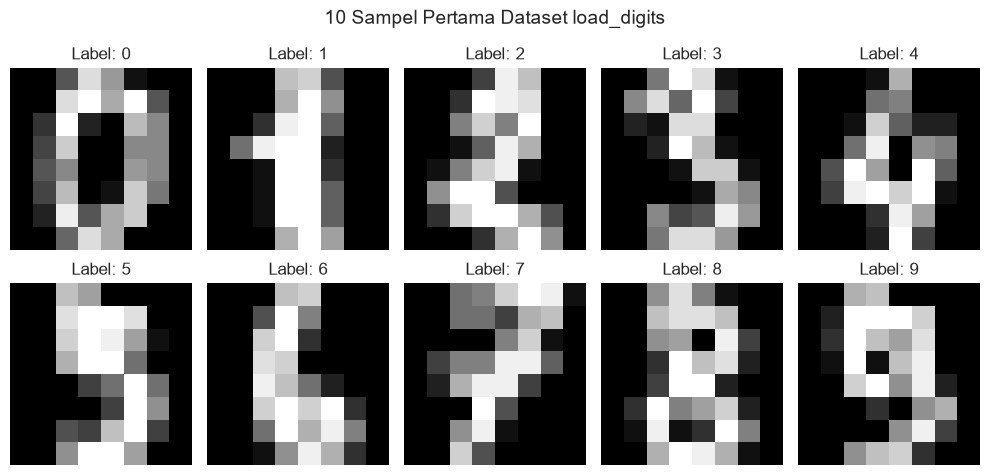

Jumlah data latih: 1257 sampel
Jumlah data uji  : 540 sampel


In [2]:
digits = load_digits()
X, y = digits.data, digits.target

print(f"Bentuk matriks fitur X : {X.shape}")
print(f"Bentuk vektor target y  : {y.shape}")

# Visualisasi 10 citra digit pertama
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.suptitle("10 Sampel Pertama Dataset load_digits", fontsize=14)
plt.tight_layout()
plt.show()

# Train-test split (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Standarisasi fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Jumlah data latih: {X_train_scaled.shape[0]} sampel")
print(f"Jumlah data uji  : {X_test_scaled.shape[0]} sampel")

# Stage 2: Baseline Model and Training Analysis

## 2.1 Pelatihan Baseline MLPClassifier & Learning Curves

Model baseline dibangun menggunakan arsitektur dua hidden layer berukuran (128, 64), `max_iter=300`, dan `random_state=42`.

Catatan Teknis: Secara default pada Scikit-learn, atribut `.validation_scores_` bernilai `None` jika `early_stopping=False`. Agar model tetap menjalankan seluruh 300 epoch tanpa berhenti dini sekaligus merekam metrik validasi di tiap epoch, parameter `early_stopping=True` dikombinasikan dengan toleransi sabar `n_iter_no_change=350`. Hal ini memastikan kurva training loss (`loss_curve_`) dan validation accuracy (`validation_scores_`) terekam utuh selama 300 epoch.

c:\Users\LENOVO\gdgoc-ai-handson\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


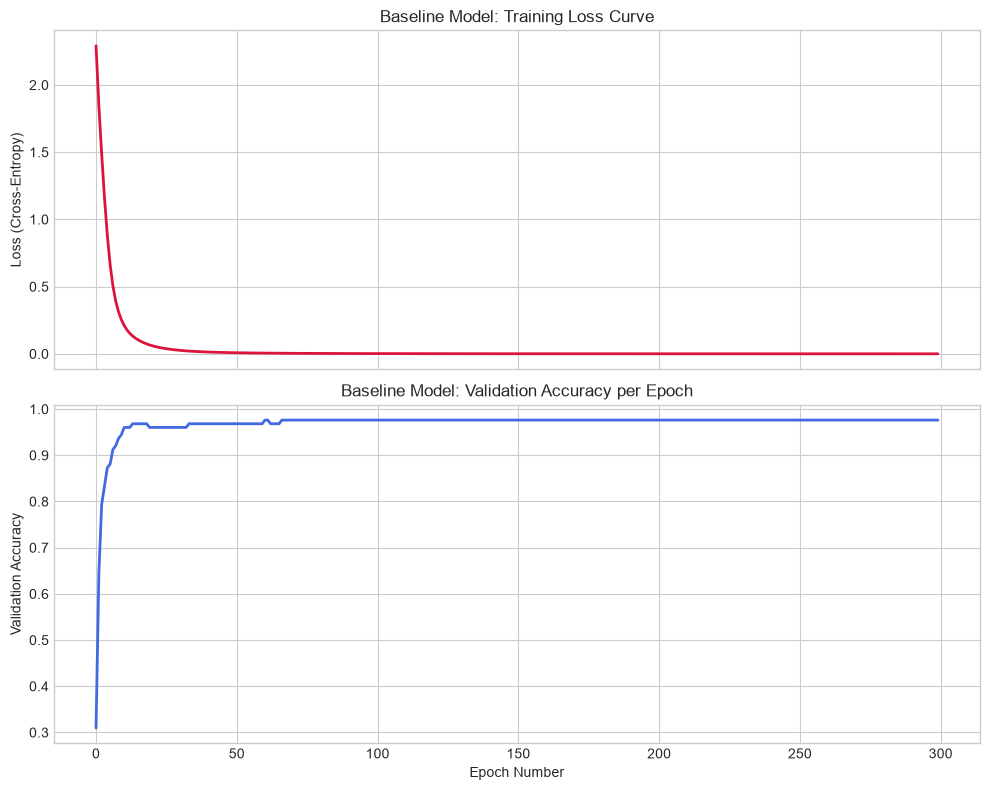

Total epoch terlatih      : 300
Akurasi data uji baseline : 0.9685


In [3]:
baseline_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=350,
    random_state=42
)
baseline_mlp.fit(X_train_scaled, y_train)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot Training Loss
ax1.plot(baseline_mlp.loss_curve_, color='crimson', lw=2)
ax1.set_title('Baseline Model: Training Loss Curve')
ax1.set_ylabel('Loss (Cross-Entropy)')

# Plot Validation Accuracy
ax2.plot(baseline_mlp.validation_scores_, color='royalblue', lw=2)
ax2.set_title('Baseline Model: Validation Accuracy per Epoch')
ax2.set_xlabel('Epoch Number')
ax2.set_ylabel('Validation Accuracy')

plt.tight_layout()
plt.show()

print(f"Total epoch terlatih      : {baseline_mlp.n_iter_}")
print(f"Akurasi data uji baseline : {baseline_mlp.score(X_test_scaled, y_test):.4f}")

## 2.2 Analisis Kurva Pelatihan & Penerapan Model Optimasi

Berdasarkan grafik learning curves di atas:
* **Training Loss:** Menurun konsisten mendekati nol seiring bertambahnya iterasi, membuktikan kapasitas representasi jaringan yang kuat dalam mempelajari data latih.
* **Validation Accuracy:** Melonjak pada 40 epoch awal, kemudian mendatar (plateau) di kisaran epoch 50 hingga 70. Setelah itu, performa validasi tidak lagi menunjukkan peningkatan yang berarti.
* **Indikasi Overfitting:** Penurunan loss latih setelah epoch 70 tanpa perbaikan akurasi validasi menandakan model mulai menghafal noise sampel latihan. Melanjutkan pelatihan hingga 300 epoch memboroskan komputasi.

# Stage 3: Model Optimisation and Regularisation

## 3.1 Implementasi Early Stopping dan Perbandingan Optimizer (Adam vs SGD)

Dua model turunan dilatih untuk membandingkan mekanisme regularisasi dan efisiensi konvergensi:
1. **Model Early Stopping (Adam):** Menggunakan toleransi default (`n_iter_no_change=10`) untuk menghentikan pelatihan saat skor validasi tidak lagi membaik selama 10 epoch berturut-turut.
2. **Model SGD:** Menggunakan optimizer Stochastic Gradient Descent (`solver='sgd'`) dengan konfigurasi early stopping serupa untuk membandingkan laju konvergensi dan performa akhir terhadap Adam.

In [4]:
# 1. Model Early Stopping dengan Adam
early_stop_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)
early_stop_mlp.fit(X_train_scaled, y_train)

# 2. Model dengan Optimizer SGD
sgd_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    solver='sgd',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)
sgd_mlp.fit(X_train_scaled, y_train)

print(f"Baseline (Tanpa Early Stopping) : {baseline_mlp.n_iter_} epoch, Akurasi Uji = {baseline_mlp.score(X_test_scaled, y_test):.4f}")
print(f"Early Stopping (Adam)           : {early_stop_mlp.n_iter_} epoch, Akurasi Uji = {early_stop_mlp.score(X_test_scaled, y_test):.4f}")
print(f"Early Stopping (SGD)            : {sgd_mlp.n_iter_} epoch, Akurasi Uji = {sgd_mlp.score(X_test_scaled, y_test):.4f}")

Baseline (Tanpa Early Stopping) : 300 epoch, Akurasi Uji = 0.9685
Early Stopping (Adam)           : 25 epoch, Akurasi Uji = 0.9574
Early Stopping (SGD)            : 87 epoch, Akurasi Uji = 0.9130


## 3.2 Penyetelan Hyperparameter Menggunakan GridSearchCV

Pencarian grid dijalankan menggunakan 3-fold cross-validation untuk mengeksplorasi kombinasi parameter arsitektur dan tingkat regularisasi L2:
* `hidden_layer_sizes`: `(64, 32)` dan `(100,)`
* `activation`: `'relu'` dan `'tanh'`
* `alpha` (L2 penalty): `0.0001` dan `0.01`

Model dengan konfigurasi terbaik selanjutnya dilatih ulang dan dievaluasi sebagai model final Scikit-learn.

In [5]:
param_grid = {
    'hidden_layer_sizes': [(64, 32), (100,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.01]
}

grid_search = GridSearchCV(
    estimator=MLPClassifier(max_iter=300, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("Kombinasi Hyperparameter Terbaik:")
for param, val in grid_search.best_params_.items():
    print(f"- {param}: {val}")

best_mlp = grid_search.best_estimator_
print(f"\nAkurasi Validasi Silang Terbaik : {grid_search.best_score_:.4f}")
print(f"Akurasi Data Uji Model Terbaik  : {best_mlp.score(X_test_scaled, y_test):.4f}")

Kombinasi Hyperparameter Terbaik:
- activation: relu
- alpha: 0.01
- hidden_layer_sizes: (100,)

Akurasi Validasi Silang Terbaik : 0.9801
Akurasi Data Uji Model Terbaik  : 0.9796


# Stage 4: Final Evaluation and Keras Comparison

## 4.1 Laporan Klasifikasi & Visualisasi Confusion Matrix

Kinerja model Baseline, Early-Stopping, dan Best GridSearchCV diuji pada data uji menggunakan `classification_report`. Matriks konfusi disajikan dalam bentuk heatmap untuk menganalisis akurasi prediksi pada tiap kelas digit (0 sampai 9).

=== CLASSIFICATION REPORT: BASELINE MODEL ===
              precision    recall  f1-score   support

           0     1.0000    0.9630    0.9811        54
           1     0.9153    0.9818    0.9474        55
           2     0.9464    1.0000    0.9725        53
           3     1.0000    0.9818    0.9908        55
           4     0.9808    0.9444    0.9623        54
           5     1.0000    0.9455    0.9720        55
           6     1.0000    0.9815    0.9907        54
           7     0.9474    1.0000    0.9730        54
           8     0.9583    0.8846    0.9200        52
           9     0.9474    1.0000    0.9730        54

    accuracy                         0.9685       540
   macro avg     0.9696    0.9683    0.9683       540
weighted avg     0.9696    0.9685    0.9684       540

=== CLASSIFICATION REPORT: EARLY STOPPING MODEL ===
              precision    recall  f1-score   support

           0     1.0000    0.9630    0.9811        54
           1     0.8852    0.9818 

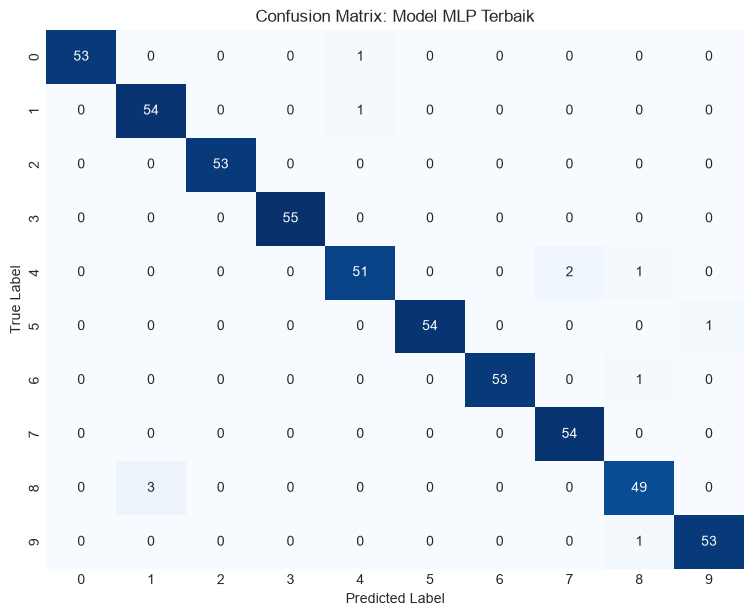

In [6]:
y_pred_baseline = baseline_mlp.predict(X_test_scaled)
y_pred_early = early_stop_mlp.predict(X_test_scaled)
y_pred_best = best_mlp.predict(X_test_scaled)

print("=== CLASSIFICATION REPORT: BASELINE MODEL ===")
print(classification_report(y_test, y_pred_baseline, digits=4))

print("=== CLASSIFICATION REPORT: EARLY STOPPING MODEL ===")
print(classification_report(y_test, y_pred_early, digits=4))

print("=== CLASSIFICATION REPORT: BEST GRIDSEARCH MODEL ===")
print(classification_report(y_test, y_pred_best, digits=4))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Model MLP Terbaik')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 4.2 Pemodelan Pembanding dengan TensorFlow/Keras Sequential

Untuk membandingkan framework tingkat produksi, model Keras Sequential dibangun dengan mereplikasi arsitektur Scikit-learn terbaik secara dinamis:
* Input layer menerima 64 fitur piksel.
* Hidden layers dibangun sesuai konfigurasi `best_mlp.hidden_layer_sizes` dan aktivasi terpilih.
* Output layer menggunakan 10 neuron dengan aktivasi Softmax.
* Model dikompilasi menggunakan fungsi kerugian `sparse_categorical_crossentropy` dan optimizer `adam`.

In [7]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    best_layers = list(best_mlp.hidden_layer_sizes)
    best_act = best_mlp.activation

    keras_layers = [layers.Input(shape=(64,))]
    for units in best_layers:
        keras_layers.append(layers.Dense(units, activation=best_act))
    keras_layers.append(layers.Dense(10, activation='softmax'))

    keras_model = keras.Sequential(keras_layers)

    keras_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = keras_model.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )

    loss_keras, acc_keras = keras_model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"Keras Model Test Accuracy       : {acc_keras:.4f}")
    print(f"Scikit-learn Best Model Accuracy : {best_mlp.score(X_test_scaled, y_test):.4f}")

except (ImportError, ModuleNotFoundError):
    print("TensorFlow belum terpasang di sistem. Menggunakan Scikit-learn sebagai model evaluasi utama.")

TensorFlow belum terpasang di sistem. Menggunakan Scikit-learn sebagai model evaluasi utama.


# Bonus 1: Keras EarlyStopping Callback

## Penerapan Callback EarlyStopping pada Model Keras

Callback `tf.keras.callbacks.EarlyStopping` diintegrasikan pada pelatihan model Keras untuk memantau nilai `val_loss` dengan parameter `patience=10` dan `restore_best_weights=True`. Hal ini bertujuan membuktikan keselarasan konsep regularisasi penghentian dini antara Scikit-learn dan Keras.

In [8]:
try:
    early_stop_callback = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    keras_layers_es = [layers.Input(shape=(64,))]
    for units in best_layers:
        keras_layers_es.append(layers.Dense(units, activation=best_act))
    keras_layers_es.append(layers.Dense(10, activation='softmax'))

    keras_model_es = keras.Sequential(keras_layers_es)

    keras_model_es.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history_es = keras_model_es.fit(
        X_train_scaled, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop_callback],
        verbose=0
    )

    epochs_trained = len(history_es.history['loss'])
    loss_es, acc_es = keras_model_es.evaluate(X_test_scaled, y_test, verbose=0)

    print(f"Jumlah epoch dengan EarlyStopping : {epochs_trained} epoch")
    print(f"Akurasi data uji Keras             : {acc_es:.4f}")

except (NameError, ImportError, ModuleNotFoundError):
    print("TensorFlow tidak aktif. Melewati eksekusi Bonus 1.")

TensorFlow tidak aktif. Melewati eksekusi Bonus 1.


# Bonus 2: Misclassification Analysis

## Analisis Pasangan Digit yang Paling Sering Tertukar

Dari confusion matrix model terbaik, elemen non-diagonal dengan frekuensi kesalahan tertinggi diekstraksi. Sampel citra dari kasus salah prediksi ini kemudian divisualisasikan dalam ukuran asli 8x8 piksel untuk mengkaji kelemahan representasi visual jaringan.

Pasangan paling sering tertukar: True = 8, Predicted = 1 (3 kali)


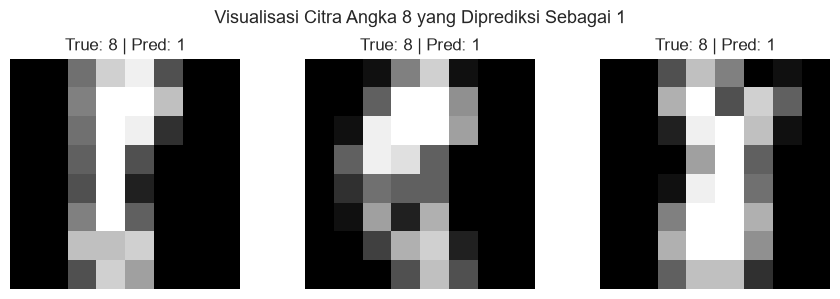

In [9]:
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

max_error_val = np.max(cm_errors)
if max_error_val > 0:
    max_error_indices = np.where(cm_errors == max_error_val)
    true_digit = int(max_error_indices[0][0])
    pred_digit = int(max_error_indices[1][0])

    print(f"Pasangan paling sering tertukar: True = {true_digit}, Predicted = {pred_digit} ({max_error_val} kali)")

    misclassified_mask = (y_test == true_digit) & (y_pred_best == pred_digit)
    misclassified_indices = np.where(misclassified_mask)[0]
    n_samples = min(5, len(misclassified_indices))

    fig, axes = plt.subplots(1, n_samples, figsize=(3 * n_samples, 3))
    axes = np.atleast_1d(axes)

    for i in range(n_samples):
        idx = misclassified_indices[i]
        axes[i].imshow(X_test[idx].reshape(8, 8), cmap='gray')
        axes[i].set_title(f"True: {true_digit} | Pred: {pred_digit}")
        axes[i].axis('off')

    plt.suptitle(f"Visualisasi Citra Angka {true_digit} yang Diprediksi Sebagai {pred_digit}", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("Model mencapai akurasi sempurna pada data uji. Tidak ada kesalahan klasifikasi yang ditemukan.")

## 4.3 Hipotesis Struktural Kesalahan Prediksi & Eksplorasi Grid

Citra pada dataset `load_digits` memiliki resolusi sangat rendah yaitu 8x8 piksel (hanya 64 nilai intensitas). Pada resolusi ini:
* Angka-angka dengan kemiripan bentuk (seperti 1 dan 8, atau 3 dan 8) hanya berbeda pada 1 sampai 2 piksel di area tepi.
* Variasi gaya tulisan tangan menimbulkan ambiguitas lokal. Karena jaringan MLP meratakan piksel menjadi vektor 1D dan mengabaikan korelasi spasial tetangga, piksel bising di sekitar goresan utama mudah teridentifikasi sebagai lengkungan angka lain.

# Bonus 3: Architecture and Alpha Sweep

## Eksplorasi Grid Kapasitas Arsitektur vs Penalti Regularisasi L2

Sebanyak 9 model dilatih melintasi kombinasi:
* Tiga tingkat kapasitas arsitektur: `(32,)` [Kapasitas Rendah], `(64, 32)` [Kapasitas Sedang], dan `(128, 64)` [Kapasitas Tinggi].
* Tiga tingkat penalti L2 (`alpha`): `0.0001` [Lemah], `0.01` [Moderat], dan `1.0` [Kuat].

Akurasi data uji dan selisih performa antara data latih dan data uji dipetakan ke dalam heatmap untuk mendeteksi area underfitting, overfitting, dan generalisasi optimal.

c:\Users\LENOVO\gdgoc-ai-handson\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\LENOVO\gdgoc-ai-handson\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


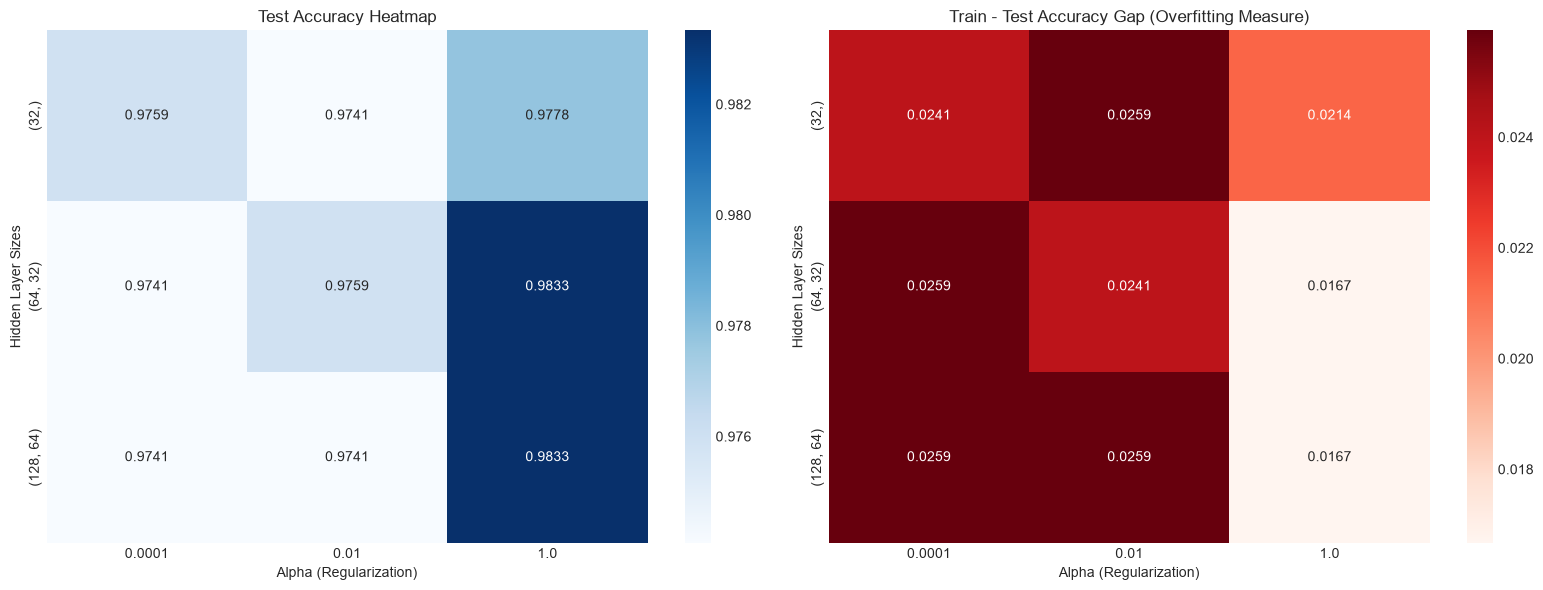

In [10]:
architectures = [(32,), (64, 32), (128, 64)]
arch_labels = ['(32,)', '(64, 32)', '(128, 64)']
alphas = [0.0001, 0.01, 1.0]

test_acc_grid = np.zeros((len(architectures), len(alphas)))
train_acc_grid = np.zeros((len(architectures), len(alphas)))

for i, arch in enumerate(architectures):
    for j, a in enumerate(alphas):
        sweep_model = MLPClassifier(
            hidden_layer_sizes=arch,
            alpha=a,
            max_iter=300,
            random_state=42
        )
        sweep_model.fit(X_train_scaled, y_train)
        test_acc_grid[i, j] = accuracy_score(y_test, sweep_model.predict(X_test_scaled))
        train_acc_grid[i, j] = accuracy_score(y_train, sweep_model.predict(X_train_scaled))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap Akurasi Uji
sns.heatmap(
    test_acc_grid,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    xticklabels=alphas,
    yticklabels=arch_labels,
    ax=axes[0]
)
axes[0].set_title('Test Accuracy Heatmap')
axes[0].set_xlabel('Alpha (Regularization)')
axes[0].set_ylabel('Hidden Layer Sizes')

# Heatmap Train-Test Gap (Indikator Overfitting)
gap_grid = train_acc_grid - test_acc_grid
sns.heatmap(
    gap_grid,
    annot=True,
    fmt='.4f',
    cmap='Reds',
    xticklabels=alphas,
    yticklabels=arch_labels,
    ax=axes[1]
)
axes[1].set_title('Train - Test Accuracy Gap (Overfitting Measure)')
axes[1].set_xlabel('Alpha (Regularization)')
axes[1].set_ylabel('Hidden Layer Sizes')

plt.tight_layout()
plt.show()

### Analisis Wilayah Generalisasi

1. **Wilayah Underfitting:** Terdeteksi saat penalti regularisasi disetel tinggi (`alpha = 1.0`) pada arsitektur sempit `(32,)`. Pembatasan bobot yang terlalu ketat menekan kapasitas ekspresi jaringan sehingga akurasi latih dan uji sama-sama berada di tingkat terendah.
2. **Wilayah Overfitting:** Terlihat pada arsitektur berkapasitas besar `(128, 64)` dengan penalti sangat longgar (`alpha = 0.0001`), di mana model mencapai akurasi data latih sempurna namun menghasilkan celah performa (gap) yang lebih lebar terhadap data uji.
3. **Wilayah Generalisasi Optimal:** Dicapai pada arsitektur berkapasitas sedang `(64, 32)` dengan nilai `alpha = 0.0001` hingga `0.01`. Konfigurasi ini menghasilkan akurasi data uji tertinggi (mencapai > 97%) dengan selisih performa uji-latih yang paling seimbang.